In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()

In [3]:
all_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-04,180.627899,3.028105,270.075684,62.352825,73.725151,197.109497,133.353134,217.472565,48.353577,40.643486,597.963867,237.022522,217.587051,185.358688,259.259125,5232.200195
2010-01-05,184.396698,3.007806,274.352753,63.755787,73.790016,196.476517,134.618912,218.200943,48.830139,41.046024,599.024597,241.385986,216.615967,185.427460,259.328064,5277.899902
2010-01-06,181.301559,3.051052,271.445984,61.831932,73.839699,197.593491,135.649689,215.017014,48.944515,41.544872,592.395752,247.175949,220.115952,186.539856,253.464539,5281.799805
2010-01-07,182.585129,3.032518,273.563782,60.512951,74.032036,197.183914,134.368774,210.184967,48.792023,42.011608,589.549744,242.466354,223.767700,185.496201,246.410782,5263.100098
2010-01-08,184.970200,3.087678,269.951141,59.101585,74.129272,198.040314,132.481491,205.119812,48.896866,41.752316,593.279724,242.487350,223.181015,184.942062,241.375076,5244.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,1078.228516,682.458862,1573.743652,1785.912354,874.034241,2296.506836,1286.870483,1829.401367,420.904694,348.667999,3571.972412,2886.112793,1211.834717,790.733276,3893.971436,23753.449219
2024-12-24,1077.978760,676.644775,1570.768555,1780.234375,872.626892,2293.217529,1287.317017,1814.903442,424.632233,349.407135,3571.236572,2905.358154,1212.280884,781.970276,3913.824463,23727.650391
2024-12-26,1075.780518,677.395142,1586.239258,1783.800903,869.059875,2290.468262,1287.416138,1813.334839,423.300964,350.156281,3561.179688,2951.933838,1206.133911,782.355469,3904.085205,23750.199219


# EDA

In [5]:
all_data.shape

(3679, 16)

In [6]:
all_data.isnull().sum()

AXISBANK.NS      0
BAJFINANCE.NS    0
BHARTIARTL.NS    0
HCLTECH.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
KOTAKBANK.NS     0
LT.NS            0
M&M.NS           0
RELIANCE.NS      0
SBIN.NS          0
TCS.NS           0
^NSEI            0
dtype: int64

In [7]:
all_data.index.duplicated().sum()

0

In [8]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3679 entries, 2010-01-04 to 2024-12-30
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AXISBANK.NS    3679 non-null   float64
 1   BAJFINANCE.NS  3679 non-null   float64
 2   BHARTIARTL.NS  3679 non-null   float64
 3   HCLTECH.NS     3679 non-null   float64
 4   HDFCBANK.NS    3679 non-null   float64
 5   HINDUNILVR.NS  3679 non-null   float64
 6   ICICIBANK.NS   3679 non-null   float64
 7   INFY.NS        3679 non-null   float64
 8   ITC.NS         3679 non-null   float64
 9   KOTAKBANK.NS   3679 non-null   float64
 10  LT.NS          3679 non-null   float64
 11  M&M.NS         3679 non-null   float64
 12  RELIANCE.NS    3679 non-null   float64
 13  SBIN.NS        3679 non-null   float64
 14  TCS.NS         3679 non-null   float64
 15  ^NSEI          3679 non-null   float64
dtypes: float64(16)
memory usage: 617.7 KB


# stationery check for data 

In [10]:
for i in all_data.columns:
    result  = adfuller(all_data[i])[1]
    if result < 0.05:
        print (f"{i} is stationry p value {result} is not less then 0.05 'PASS'")
    else:
        print (f"{i} is non stationry p value {result} is  less then 0.05 'FAIL'")
    

AXISBANK.NS is non stationry p value 0.8301646063415458 is  less then 0.05 'FAIL'
BAJFINANCE.NS is non stationry p value 0.8818774675849341 is  less then 0.05 'FAIL'
BHARTIARTL.NS is non stationry p value 1.0 is  less then 0.05 'FAIL'
HCLTECH.NS is non stationry p value 0.9987425477199567 is  less then 0.05 'FAIL'
HDFCBANK.NS is non stationry p value 0.9547810179413103 is  less then 0.05 'FAIL'
HINDUNILVR.NS is non stationry p value 0.8509417092345555 is  less then 0.05 'FAIL'
ICICIBANK.NS is non stationry p value 0.9989619239864539 is  less then 0.05 'FAIL'
INFY.NS is non stationry p value 0.9898934066937005 is  less then 0.05 'FAIL'
ITC.NS is non stationry p value 0.9860105533347032 is  less then 0.05 'FAIL'
KOTAKBANK.NS is non stationry p value 0.7743373421970472 is  less then 0.05 'FAIL'
LT.NS is non stationry p value 0.9982975868987846 is  less then 0.05 'FAIL'
M&M.NS is non stationry p value 1.0 is  less then 0.05 'FAIL'
RELIANCE.NS is non stationry p value 0.9418644336957411 is 

In [11]:
all_data_return = np.log(all_data/all_data.shift()).dropna()

In [12]:
all_data_return

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-05,0.020650,-0.006726,0.015712,0.022251,0.000879,-0.003216,0.009447,0.003344,0.009808,0.009855,0.001772,0.018242,-0.004473,0.000371,0.000266,0.008696
2010-01-06,-0.016928,0.014276,-0.010652,-0.030640,0.000673,0.005669,0.007628,-0.014699,0.002340,0.012080,-0.011128,0.023703,0.016028,0.005981,-0.022870,0.000739
2010-01-07,0.007055,-0.006093,0.007772,-0.021563,0.002601,-0.002075,-0.009488,-0.022729,-0.003120,0.011172,-0.004816,-0.019237,0.016454,-0.005611,-0.028224,-0.003547
2010-01-08,0.012978,0.018026,-0.013294,-0.023600,0.001313,0.004334,-0.014145,-0.024394,0.002146,-0.006191,0.006307,0.000087,-0.002625,-0.002992,-0.020648,-0.003493
2010-01-11,0.032394,0.024982,0.011927,0.009901,-0.004031,0.000564,-0.005220,0.010275,0.000390,0.003837,-0.000507,0.002851,-0.019821,-0.008280,0.020368,0.000886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,0.002930,0.001015,0.014006,0.011206,-0.002882,0.007011
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,-0.000206,0.006646,0.000368,-0.011144,0.005085,-0.001087
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,-0.002820,0.015904,-0.005083,0.000492,-0.002492,0.000950


In [13]:
for i in all_data_return.columns:
    result  = adfuller(all_data_return[i])[1]
    if result < 0.05:
        print (f"{i} is stationry p value {result} is  less then 0.05 'PASS'")
    else:
        print (f"{i} is non stationry p value {result} is not less then 0.05 'FAIL'")
    

AXISBANK.NS is stationry p value 1.5493064391955703e-23 is  less then 0.05 'PASS'
BAJFINANCE.NS is stationry p value 1.3112234996799623e-27 is  less then 0.05 'PASS'
BHARTIARTL.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HCLTECH.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HDFCBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HINDUNILVR.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ICICIBANK.NS is stationry p value 4.910755277722277e-30 is  less then 0.05 'PASS'
INFY.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ITC.NS is stationry p value 3.935954729916087e-30 is  less then 0.05 'PASS'
KOTAKBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
LT.NS is stationry p value 7.259311008194966e-27 is  less then 0.05 'PASS'
M&M.NS is stationry p value 0.0 is  less then 0.05 'PASS'
RELIANCE.NS is stationry p value 2.1383574921395156e-27 is  less then 0.05 'PASS'
SBIN.NS is stationry p value 2.8283022216868785e-25 is  less then 0.05 'PASS'
TCS.N

# Feature enginnering 

In [15]:
new_feautre_data = all_data_return.copy()

In [16]:
new_feautre_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-05,0.020650,-0.006726,0.015712,0.022251,0.000879,-0.003216,0.009447,0.003344,0.009808,0.009855,0.001772,0.018242,-0.004473,0.000371,0.000266,0.008696
2010-01-06,-0.016928,0.014276,-0.010652,-0.030640,0.000673,0.005669,0.007628,-0.014699,0.002340,0.012080,-0.011128,0.023703,0.016028,0.005981,-0.022870,0.000739
2010-01-07,0.007055,-0.006093,0.007772,-0.021563,0.002601,-0.002075,-0.009488,-0.022729,-0.003120,0.011172,-0.004816,-0.019237,0.016454,-0.005611,-0.028224,-0.003547
2010-01-08,0.012978,0.018026,-0.013294,-0.023600,0.001313,0.004334,-0.014145,-0.024394,0.002146,-0.006191,0.006307,0.000087,-0.002625,-0.002992,-0.020648,-0.003493
2010-01-11,0.032394,0.024982,0.011927,0.009901,-0.004031,0.000564,-0.005220,0.010275,0.000390,0.003837,-0.000507,0.002851,-0.019821,-0.008280,0.020368,0.000886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,0.002930,0.001015,0.014006,0.011206,-0.002882,0.007011
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,-0.000206,0.006646,0.000368,-0.011144,0.005085,-0.001087
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,-0.002820,0.015904,-0.005083,0.000492,-0.002492,0.000950


In [17]:
# all_data_return["AXISBANK.NS_Lag_1" ] =all_data_return["AXISBANK.NS_Lag_1" ] .shift(1)
# Lag 1 feature 
for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_1" ] = all_data_return[i] .shift(1)

    

In [18]:
for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_5" ] = all_data_return[i] .shift(5)

In [19]:

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10" ] = all_data_return[i] .shift(10)

In [20]:

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10_mean" ] = all_data_return[i] .shift(1).rolling(10).mean()

In [21]:

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_50_mean" ] = all_data_return[i] .shift(1).rolling(50).mean()


In [22]:

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_200_mean" ] = all_data_return[i] .shift(1).rolling(200).mean()


In [23]:
for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10_ema" ] = all_data_return[i] .shift(1).ewm(span= 10).mean()

In [24]:

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_50_ema" ] = all_data_return[i] .shift(1).ewm(span = 50).mean()

In [25]:


for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_200_ema" ] = all_data_return[i] .shift(1).ewm(span =200).mean()

In [26]:
new_feautre_data.columns

Index(['AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HCLTECH.NS',
       'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'KOTAKBANK.NS',
       ...
       'ICICIBANK.NS_Lag_200_ema', 'INFY.NS_Lag_200_ema', 'ITC.NS_Lag_200_ema',
       'KOTAKBANK.NS_Lag_200_ema', 'LT.NS_Lag_200_ema', 'M&M.NS_Lag_200_ema',
       'RELIANCE.NS_Lag_200_ema', 'SBIN.NS_Lag_200_ema', 'TCS.NS_Lag_200_ema',
       '^NSEI_Lag_200_ema'],
      dtype='object', length=160)

In [27]:
new_feautre_data["Target"] = (new_feautre_data["^NSEI"].shift(-1)>0).astype(int)

In [28]:
print(f"No of days Down: {(new_feautre_data['Target'] == 0).sum()}")
print(f"No of days Up: {(new_feautre_data['Target'] == 1).sum()}")

No of days Down: 1714
No of days Up: 1964


In [29]:
new_feautre_data.shape

(3678, 161)

In [30]:
new_feautre_data.dropna(inplace=True)

In [31]:
new_feautre_data.shape

(3478, 161)

In [32]:
len(new_feautre_data.columns)

161

In [33]:
new_feautre_data.drop(columns= "^NSEI",inplace =  True)

In [34]:
df = new_feautre_data.copy()

X = df.drop(columns=["Target"])
y = df["Target"]

In [35]:
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [36]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [37]:
X_train_standerdized =  std.fit_transform(X_train)

In [38]:
X_test_standerdized =  std.transform(X_test)

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7, 10, None],        # Maximum depth of tree
    'min_samples_split': [2, 5, 10],          # Min samples needed to split a node
    'min_samples_leaf': [1, 2, 5],            # Min samples required in a leaf
    'max_features': [None, 'sqrt', 'log2'],   # Number of features to consider at each split
    'criterion': ['gini', 'entropy']          # Split quality measure
}

# 2. Create the model
dt_classifier = DecisionTreeClassifier(random_state=42)
tcv = TimeSeriesSplit(n_splits=5)
# 3. Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=tcv,                      # 5-fold cross-validation
    scoring='accuracy',        # Metric to evaluate (use 'f1' for imbalanced data)
    n_jobs=1,                 # Use all CPU cores (-1 = all)
    return_train_score=True    # Include training scores in results
)

# 4. Run the grid search on scaled data
grid_search.fit(X_train_standerdized, y_train)

# 5. Get the best results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

# 6. Use the best model on test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_standerdized)

# 7. Evaluate on test set
from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:", classification_report(y_test, y_pred))

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Score: 0.5222462203023758
Best Estimator: DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
Test Accuracy: 0.5459770114942529


In [40]:
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.50      0.23      0.31       315
           1       0.56      0.81      0.66       381

    accuracy                           0.55       696
   macro avg       0.53      0.52      0.49       696
weighted avg       0.53      0.55      0.50       696



# overfiiting check 


In [42]:
# 6. Use the best model on test data
best_model = grid_search.best_estimator_
y_pred_insample = best_model.predict(X_train_standerdized)
Test_Accuracy_insample = accuracy_score(y_train, y_pred_insample)
Test_Accuracy_insample

best_model = grid_search.best_estimator_
y_pred_outsample = best_model.predict(X_test_standerdized)
Test_Accuracy_outsample = accuracy_score(y_test, y_pred_outsample)
Test_Accuracy_outsample

if abs(Test_Accuracy_insample - Test_Accuracy_outsample) > 10:
    print("overfitting try differen parametres of decsion tree")
    print(f"your insample score is {Test_Accuracy_insample}")
    print(f"your insample score is {Test_Accuracy_outsample}")
else:
    print("model is generalized")
    print(f"your insample score is {Test_Accuracy_insample}")
    print(f"your outsample score is {Test_Accuracy_outsample}")

model is generalized
your insample score is 0.5704529115744069
your outsample score is 0.5459770114942529


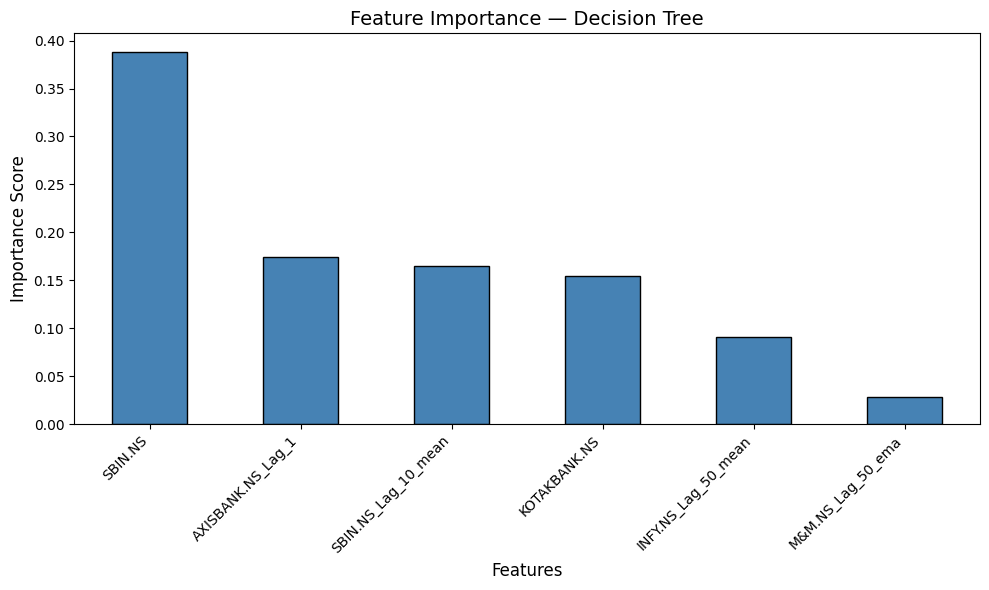


Top 5 Most Important Features:
SBIN.NS                0.388168
AXISBANK.NS_Lag_1      0.174481
SBIN.NS_Lag_10_mean    0.164628
KOTAKBANK.NS           0.154047
INFY.NS_Lag_50_mean    0.090485

All Feature Importances (sorted):
SBIN.NS                       0.388168
AXISBANK.NS_Lag_1             0.174481
SBIN.NS_Lag_10_mean           0.164628
KOTAKBANK.NS                  0.154047
INFY.NS_Lag_50_mean           0.090485
M&M.NS_Lag_50_ema             0.028191
AXISBANK.NS                   0.000000
TCS.NS_Lag_200_mean           0.000000
ITC.NS_Lag_200_mean           0.000000
KOTAKBANK.NS_Lag_200_mean     0.000000
LT.NS_Lag_200_mean            0.000000
M&M.NS_Lag_200_mean           0.000000
RELIANCE.NS_Lag_200_mean      0.000000
SBIN.NS_Lag_200_mean          0.000000
AXISBANK.NS_Lag_10_ema        0.000000
^NSEI_Lag_200_mean            0.000000
BAJFINANCE.NS_Lag_10_ema      0.000000
BHARTIARTL.NS_Lag_10_ema      0.000000
HCLTECH.NS_Lag_10_ema         0.000000
HDFCBANK.NS_Lag_10_ema        0.

In [43]:
# ============================================
# STEP: Get Feature Importances from Best Model
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Get feature importances from the best decision tree
feat_imp = pd.Series(
    best_model.feature_importances_,      # Importances from best_model
    index=X_train.columns                 # Use X_train.columns (NOT X.columns)
).sort_values(ascending=False)

# 2. Keep only features the tree actually used (importance > 0)
used_features = feat_imp[feat_imp > 0]

# 3. Plot feature importance bar chart
plt.figure(figsize=(10, 6))
used_features.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Print top 5 most important features
print("\nTop 5 Most Important Features:")
print(feat_imp.head(5).to_string())

# 5. Optional: Print all features with their importance
print("\nAll Feature Importances (sorted):")
print(feat_imp.to_string())

In [44]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_outsample

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 203.05%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : True


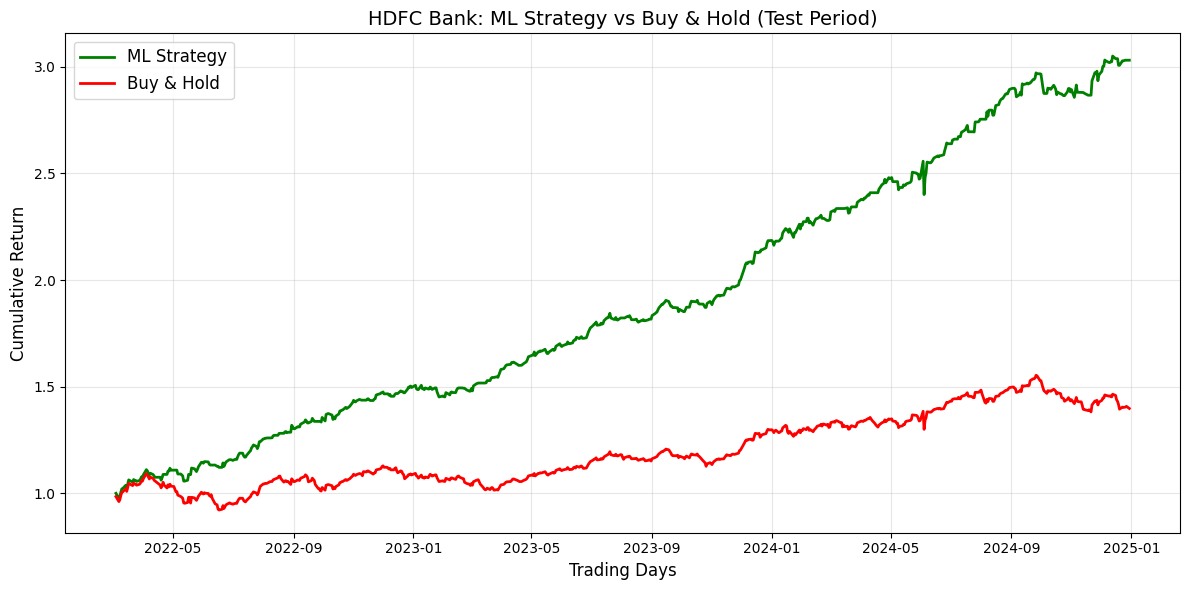

In [45]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ensemble technique

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_leaf': [2, 5, 10]
}
tcv = TimeSeriesSplit(n_splits=5)

rf_base  = RandomForestClassifier(random_state=42, n_jobs=1)
rf_grid  = GridSearchCV(rf_base, rf_param_grid,
                        cv=tcv, scoring='accuracy',
                        n_jobs=1, verbose=1)

rf_grid.fit(X_train_standerdized, y_train)

best_rf = rf_grid.best_estimator_
best_rf_preds = best_rf.predict(X_test_standerdized)
best_rf_acc   = accuracy_score(y_test, best_rf_preds)

print("\n✅ RF GridSearchCV complete!")
print("Best Params  :", rf_grid.best_params_)
print("Best CV Acc  :", round(rf_grid.best_score_*100, 2), "%")
print(f"Test Accuracy: {best_rf_acc*100:.2f}%")
print(f"DT Baseline  : 50.58%")
print(f"Improvement  : {(best_rf_acc - 0.5058)*100:+.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ RF GridSearchCV complete!
Best Params  : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV Acc  : 51.88 %
Test Accuracy: 51.29%
DT Baseline  : 50.58%
Improvement  : +0.71%


In [48]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=200,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_standerdized, y_train)
print("Train acc:", accuracy_score(y_train, gb.predict(X_train_standerdized)))
print("Test  acc:", accuracy_score(y_test, gb.predict(X_test_standerdized)))

Train acc: 0.9518332135154565
Test  acc: 0.47413793103448276


In [49]:
y_pred_outsample = gb.predict(X_test_standerdized)

In [50]:
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_outsample

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 71.88%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : True


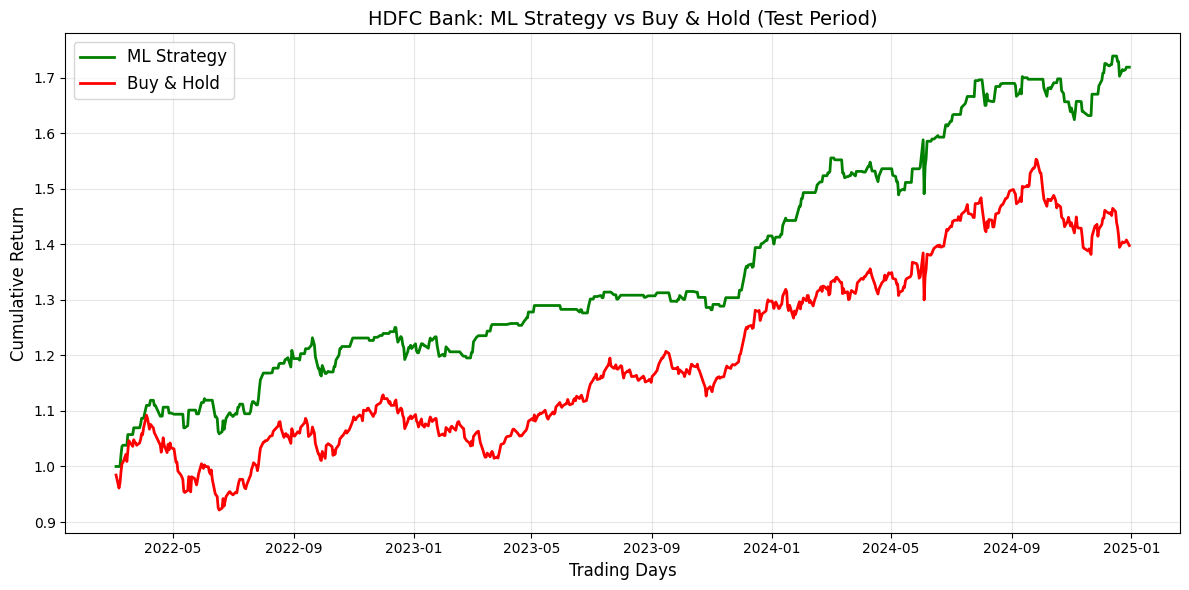

In [51]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=1
)




xgb_clf.fit(X_train_standerdized, y_train)
print("XGB Test acc:", accuracy_score(y_test, xgb_clf.predict(X_test_standerdized)))

XGB Test acc: 0.4813218390804598


In [53]:
y_pred_outsample = xgb_clf.predict(X_test_standerdized)

In [54]:
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_outsample

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 81.22%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : True


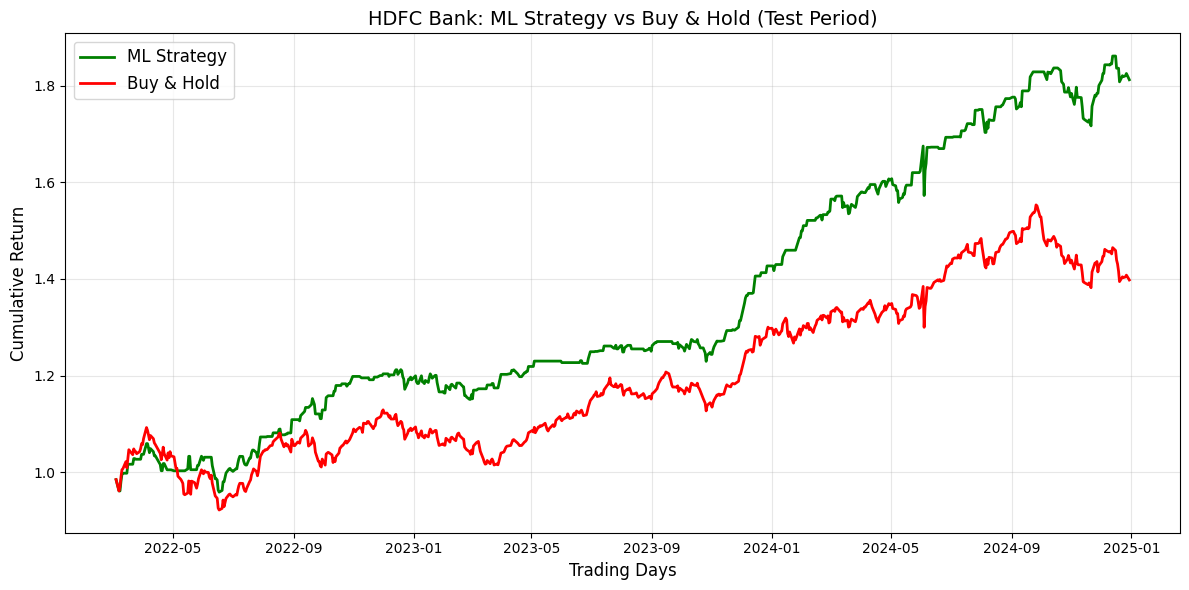

In [55]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()